<a href="https://colab.research.google.com/github/hindhammad24/Hammad_Hind_LabTask/blob/main/labtask02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 📚 Lab Task 2: Cleaning Up the Mess

You’ll be working with a dataset of real student grades — 7 assignments and a final exam — but things aren’t as clean as they should be. Some values are missing, some are way off, and it’s your job to fix it.

You’ll explore the data, figure out what went wrong, and try different strategies to clean it up.

Get ready to:
- Spot broken data
- Try out different fixes
- Compare models
- Justify your decisions

### Dataset Introduction

The dataset comes from real student grades in a course at SFU. Students completed **7 assignments**, and we also have their **final exam grade**.

It’s your job to explore the dataset and clean it up.

---

> 💡 **Note**: Students could receive bonus marks for some assignments:
> - **A2**: up to **15** points
> - **A4**: up to **5** points
> - **A6**: up to **10** points  
> Keep this in mind when you're evaluating high or unusual scores — they might not be errors!


**Attention:** The bonus values are in **points** not **percentages**!!!
---

### ✅ What You Need to Do

-  **Explore the dataset**
  - Look at basic stats, column names, and what the data looks like
  - Identify anything that stands out right away

-  **Check the correlations**
  - Use a correlation matrix to find relationships between assignments and the final exam
  - Do any assignments seem strongly related to final exam performance?

-  **If you could only use two assignment grades to predict the final exam**, which ones would you choose — and why?

-  **Check for missing values**
  - Which columns have them?
  - How many are missing?

-  **Handle the missing values**
  - Try out different imputation strategies (mean, median, remove, etc.)
  - Which one gives you the best results? Why do you think that is?
  - Exploration idea: search and see what are the ways of evaluating your results. How can you make sure that a strategy for handling the missing values works better than the other?

-  **Check for outliers**
  - Identify values that seem unrealistic or suspicious
  - Decide whether to keep, modify, or remove them — and explain your reasoning
  - Compare the results

---

For each step, be ready to explain your decisions. There isn’t always one "right" answer — we’re more interested in your reasoning!

> 💡 **Note**: If handling missing values and outliers for **all 7 assignments** feels overwhelming, it’s totally fine to **focus on just the two columns you think are most important**.  
> Just make sure your reasoning for choosing them is solid and clearly explained.


### IMPORTING AND LOADING FILE

importing pandas

In [ ]:
import pandas as pd

connecting to google drive where i saved the dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


loading the dataset from drive

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/grades_crpt (1).csv")

reading the dataset to make sure it loaded

In [ ]:
df.head()

,A1,A2,A3,A4,A5,A6,A7,Final_Exam,user_id
0,NaN,NaN,30.0,75.0,90.0,65.0,50.6,68.8,U001
1,100.0,NaN,NaN,92.5,100.0,100.0,84.4,50.3,U002
2,75.0,69.6,NaN,86.2,100.0,NaN,NaN,67.8,U003
3,25.0,78.6,40.0,0.0,50.0,30.7,0.0,0.0,U004
4,0.0,NaN,0.0,0.0,NaN,NaN,NaN,0.0,U005


explanation:
I started by importing pandas because pandas is used to load and work with the dataset. After loading the dataset into a DataFrame called df, I used df.head() to check that the file loaded correctly and to preview the first few rows as per the lab.

### Exploreing Dataset

shows the columns, data types, and how many values are missing in each column.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   A1          57 non-null     float64
 1   A2          61 non-null     float64
 2   A3          62 non-null     float64
 3   A4          77 non-null     float64
 4   A5          61 non-null     float64
 5   A6          67 non-null     float64
 6   A7          76 non-null     float64
 7   Final_Exam  86 non-null     float64
 8   user_id     86 non-null     object 
dtypes: float64(8), object(1)
memory usage: 6.2+ KB


gives summary statistics like average, minimum, and maximum to help spot unusual values.

In [ ]:
df.describe()

,A1,A2,A3,A4,A5,A6,A7,Final_Exam
count,57.000000,61.000000,62.000000,77.000000,61.000000,67.000000,76.000000,86.000000
mean,83.671930,81.096721,68.174194,82.332468,89.645902,74.437313,78.130263,55.509302
std,34.286481,28.556721,42.343621,39.101984,25.510505,31.176535,26.412058,18.176777
min,-4.500000,-30.600000,-70.100000,-21.600000,7.700000,-17.000000,0.000000,0.000000
25%,75.800000,64.300000,50.000000,72.000000,87.000000,60.000000,70.300000,45.850000
50%,87.500000,91.100000,80.000000,87.500000,95.000000,80.000000,80.000000,56.050000
75%,95.800000,100.000000,93.250000,95.000000,100.000000,92.500000,87.500000,67.725000
max,174.600000,148.900000,152.200000,188.200000,173.900000,183.600000,150.600000,97.500000


After exploring the dataset using head(), info(), and describe(), several patterns stood out right away. The dataset contains 86 students and includes seven assignment grades, the final exam grade, and a user ID column. Many of the assignment columns contain missing values, while the Final_Exam column is complete. I also noticed several unusual grade values, including negative marks in some assignments and values well above 100 but some are bonus. Since bonus marks were allowed for A2, A4, and A6, some higher values may be valid, but the negative values appear suspicious and may need to be cleaned later. The assignment averages are generally higher than the final exam average, which may suggest students performed better on assignments than on the exam but still not sure need to clean it up.

### Check correlations

checks how strongly each assignment relates to the others and the final exam.

In [ ]:
df.corr(numeric_only=True)

,A1,A2,A3,A4,A5,A6,A7,Final_Exam
A1,1.000000,-0.141322,0.363341,0.299973,0.242348,0.233172,-0.020569,0.212839
A2,-0.141322,1.000000,0.209836,-0.027420,0.011602,0.356759,0.031056,0.284525
A3,0.363341,0.209836,1.000000,0.189807,0.191534,-0.032497,0.145332,0.277859
A4,0.299973,-0.027420,0.189807,1.000000,0.039064,0.146504,0.223921,0.403466
A5,0.242348,0.011602,0.191534,0.039064,1.000000,0.241590,0.031902,0.018271
A6,0.233172,0.356759,-0.032497,0.146504,0.241590,1.000000,0.147876,0.246127
A7,-0.020569,0.031056,0.145332,0.223921,0.031902,0.147876,1.000000,0.380756
Final_Exam,0.212839,0.284525,0.277859,0.403466,0.018271,0.246127,0.380756,1.000000


ranks which assignments are most related to the final exam.

In [ ]:
# corr() = calculate correlations between numeric columns
# ["Final_Exam"] = only show Final_Exam correlations
# sort_values() = sort the results
# ascending=False = highest to lowest
# so in conclusion it shows the correlation between final exam and everythign else to show which one is the best
df.corr(numeric_only=True)["Final_Exam"].sort_values(ascending=False)

,Final_Exam
Final_Exam,1.000000
A4,0.403466
A7,0.380756
A2,0.284525
A3,0.277859
A6,0.246127
A1,0.212839
A5,0.018271


creates a visual correlation chart so relationships are easier to see. for me i struggled more understanding this

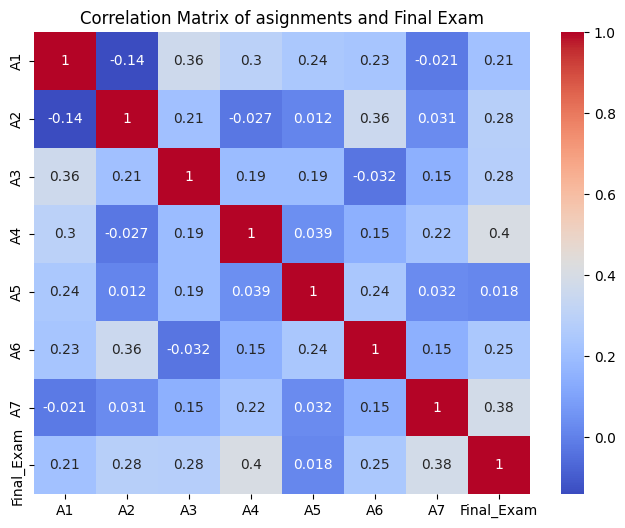

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(8,6))  # creates a new figure and sets width and height

# heatmap() creates the chart
# df.corr(numeric_only=True) calculates correlations using only numeric columns
# annot=True shows the correlation values inside each box
# cmap="coolwarm" adds color to make patterns easier to see
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.title("Correlation Matrix of asignments and Final Exam")
plt.show()

I used a correlation matrix to examine the relationship between each assignment grade and the final exam. Most assignments showed a positive correlation with the final exam, which suggests that students who performed better on assignments generally also performed better on the exam. The strongest relationships were A4 (0.403) and A7 (0.381), making them the best predictors of final exam performance in this dataset. A2 and A3 also showed moderate positive relationships, while A5 had almost no correlation with the final exam (0.018), suggesting it was not a strong predictor. If I could only choose two assignment grades to predict final exam performance, I would choose A4 and A7 because they had the highest positive correlations and appeared to be the most strongly related to student exam outcomes.

### Checkign for missing values

counts the number of missing values

In [ ]:
df.isnull().sum()

,0
A1,29
A2,25
A3,24
A4,9
A5,25
A6,19
A7,10
Final_Exam,0
user_id,0


I checked for missing values using isnull().sum(). The results showed that every assignment column contained missing values, while Final_Exam and user_id had no missing values. A1 had the highest number of missing values (29), followed by A2 and A5 with 25 each. A4 and A7 had fewer missing values compared with the other assignments. This confirms that missing grades need to be handled before continuing with analysis.

### Handle the missing values

Mean imputation

In [ ]:
df_mean = df.copy()   # makes a copy so the original dataset stays unchanged

df_mean["A4"] = df_mean["A4"].fillna(df_mean["A4"].mean())   # replaces missing A4 values with the average
df_mean["A7"] = df_mean["A7"].fillna(df_mean["A7"].mean())   # replaces missing A7 values with the average

df_mean[["A4","A7"]].isnull().sum()   # checks if missing values are gone

,0
A4,0
A7,0


for mean imputation, I replaced the missing values with the average of each column. After checking again, both columns had zero missing values. Based on this, I think mean imputation works well for keeping the full dataset, but it may be affected by very high or negative grade values.

Median imputation

In [ ]:
df_median = df.copy()   # creates another copy

df_median["A4"] = df_median["A4"].fillna(df_median["A4"].median())   # fills A4 with median
df_median["A7"] = df_median["A7"].fillna(df_median["A7"].median())   # fills A7 with median

df_median[["A4","A7"]].isnull().sum()   # confirms no missing values remain

,0
A4,0
A7,0


For median imputation, I replaced the missing values in which is the middle value of each column. Based on class the median is often useful when there are unusual values because it is less affected by outliers. Based on this I believe median imputation is more reliable for this dataset because there are some extreme values and it still keeps all students in the dataset.

Remove Rows

In [ ]:
df_drop = df.dropna(subset=["A4","A7"])   # removes rows where A4 or A7 are missing

df_drop[["A4","A7"]].isnull().sum()   # checks again

,0
A4,0
A7,0


For this method, I removed rows instead of replacing them. Based on class, this avoids estimating values and only keeps complete observations. Based on this, I think removing rows is the most accurate for using only real values, but it also removes useful student data.

I tested three strategies for handling missing values in A4 and A7 only since they where the ones i understood most. Mean imputation keeps all students but can be influenced by extreme values. Median imputation also keeps all students and is less affected by unusual grades or outliers. Removing rows avoids estimating values, but it reduces the dataset size and removes useful information. Because this dataset contains unusually high and negative values, median imputation gave the most reliable results since it keeps the full dataset while being less affected by extreme values.

### Exploration idea

Exploration idea: search and see what are the ways of evaluating your results. How can you make sure that a strategy for handling the missing values works better than the other?

After searching online and asking AI about ways to evaluate different missing value strategies, I found a few useful ways to compare them. The main ones were checking how much of the dataset is kept after cleaning, comparing summary statistics like the mean and median before and after, and checking whether relationships like correlations stay similar after handling the missing values.

Check how many rows were kept

In [ ]:
print("Original:", len(df))
print("Mean:", len(df_mean))
print("Median:", len(df_median))
print("Drop rows:", len(df_drop))

Original: 86
Mean: 86
Median: 86
Drop rows: 70


After comparing the number of rows kept after each missing value strategy, mean and median imputation both kept all 86 students in the dataset. Removing rows reduced the dataset to 70 students, which means 16 student records were removed.

Compare summary stats

In [ ]:
print("Original")
print(df[["A4","A7"]].describe())

print("Mean")
print(df_mean[["A4","A7"]].describe())

print("Median")
print(df_median[["A4","A7"]].describe())

print("Drop rows")
print(df_drop[["A4","A7"]].describe())

Original
               A4          A7
count   77.000000   76.000000
mean    82.332468   78.130263
std     39.101984   26.412058
min    -21.600000    0.000000
25%     72.000000   70.300000
50%     87.500000   80.000000
75%     95.000000   87.500000
max    188.200000  150.600000
Mean
               A4          A7
count   86.000000   86.000000
mean    82.332468   78.130263
std     36.973973   24.809808
min    -21.600000    0.000000
25%     75.675000   72.500000
50%     85.600000   78.465132
75%     95.000000   87.025000
max    188.200000  150.600000
Median
               A4          A7
count   86.000000   86.000000
mean    82.873256   78.347674
std     37.008191   24.817132
min    -21.600000    0.000000
25%     75.675000   72.500000
50%     87.500000   80.000000
75%     95.000000   87.025000
max    188.200000  150.600000
Drop rows
               A4          A7
count   70.000000   70.000000
mean    81.708571   76.031429
std     37.693534   24.734301
min    -21.600000    0.000000
25%     6

After comparing the summary statistics mean and median imputation both kept all 86 students and kept the values very close to the original dataset. Mean imputation kept the averages exactly the same, while median imputation kept the middle values the same as the original. Removing rows reduced the dataset to 70 students and slightly changed the averages. Based on these results, I believe median imputation worked best because it kept all students in the dataset and stayed close to the original values while also being less affected by unusual grades and outliers than the mean.

Compare correlations with Final_Exam

In [ ]:
print("Original")
print(df.corr(numeric_only=True)["Final_Exam"][["A4","A7"]])

print("Mean")
print(df_mean.corr(numeric_only=True)["Final_Exam"][["A4","A7"]])

print("Median")
print(df_median.corr(numeric_only=True)["Final_Exam"][["A4","A7"]])

print("Drop rows")
print(df_drop.corr(numeric_only=True)["Final_Exam"][["A4","A7"]])

Original
A4    0.403466
A7    0.380756
Name: Final_Exam, dtype: float64
Mean
A4    0.380170
A7    0.349812
Name: Final_Exam, dtype: float64
Median
A4    0.389038
A7    0.348153
Name: Final_Exam, dtype: float64
Drop rows
A4    0.346608
A7    0.324278
Name: Final_Exam, dtype: float64


After comparing the correlations with Final_Exam, mean and median imputation both stayed fairly close to the original relationships. Median imputation kept A4 at 0.389 and A7 at 0.348, which stayed close to the original values of 0.403 and 0.381. Mean imputation also stayed close, while removing rows lowered both correlations more noticeably. Based on this comparison, I believe median imputation worked best because it kept all 86 students and preserved the original relationship with the final exam better than removing rows. It also makes sense for this dataset because the median is less affected by unusual high or low grade values.

###Check for outliers


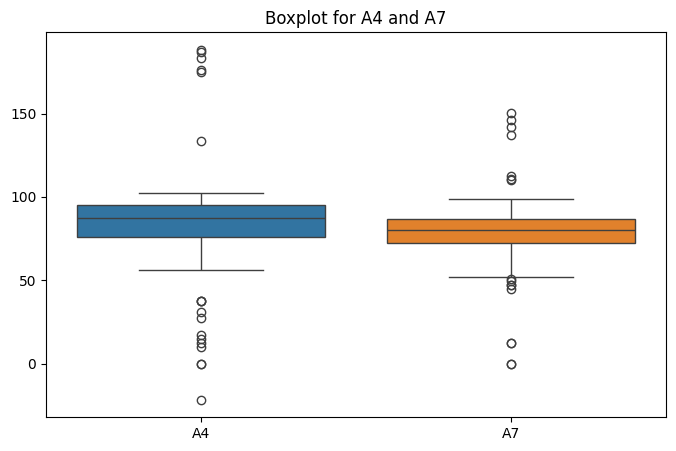

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))   # creates chart size
sns.boxplot(data=df_median[["A4","A7"]])   # boxplot shows spread and possible outliers
plt.title("Boxplot for A4 and A7")
plt.show()   # displays graph

I used boxplots and summary statistics to check for outliers in A4 and A7. This helped visualize values that were much lower or higher than the rest of the dataset. A4 showed a negative value and a very high value above the expected range. A7 also had unusually high values above 100 and some lower. These values appeared suspicious because grades are normally expected to stay within the assignment range, even when bonus marks are included.

In [ ]:
df_median[["A4","A7"]].describe()   # shows min and max values to identify suspicious grades

,A4,A7
count,86.000000,86.000000
mean,82.873256,78.347674
std,37.008191,24.817132
min,-21.600000,0.000000
25%,75.675000,72.500000
50%,87.500000,80.000000
75%,95.000000,87.025000
max,188.200000,150.600000


I used describe() on A4 and A7 after median imputation to look at the spread of the grades and check for possible outliers. Both columns now have 86 values, which confirms the missing values were filled in. The average grades are still relatively high, but the minimum and maximum values stand out. A4 has a minimum of -21.6 and a maximum of 188.2, while A7 has a maximum of 150.6. Based on this, these values seem unusual because assignment grades are normally expected to stay within the grading range, even with bonus marks. This suggests there may still be outliers that need to be reviewed before deciding whether to keep or adjust them.

In [ ]:
df_median[(df_median["A4"] < 0) | (df_median["A4"] > 105)]

,A1,A2,A3,A4,A5,A6,A7,Final_Exam,user_id
6,95.8,64.3,63.0,175.8,85.0,76.0,83.8,64.4,U007
24,130.7,NaN,85.0,188.2,100.0,80.0,85.0,68.8,U025
28,NaN,60.7,NaN,133.8,100.0,90.0,87.5,50.0,U029
30,83.3,100.0,60.0,183.1,90.0,70.0,78.8,49.1,U031
36,87.5,NaN,NaN,187.1,NaN,NaN,80.0,68.4,U037
67,90.0,100.0,83.0,-21.6,97.0,100.0,81.2,67.5,U068
82,87.5,-30.6,70.0,174.8,91.0,NaN,146.4,64.1,U083


I filtered the dataset to show rows where A4 was below 0 or above the expected maximum score. This output shows the exact students with suspicious A4 values instead of only showing the summary statistics. Several A4 scores are much higher than expected, such as 175.8, 188.2, 183.1, and 187.1, while one score is negative at -21.6. Based on this, I believe these A4 values should be treated as outliers because they are outside a realistic grading range. Since A4 only allowed up to 5 bonus points, values much higher than 105 seem suspicious and should be modified rather than kept as they are.

In [ ]:
df_median[(df_median["A7"] < 0) | (df_median["A7"] > 100)]

,A1,A2,A3,A4,A5,A6,A7,Final_Exam,user_id
5,100.0,92.9,100.0,96.2,NaN,80.0,110.5,97.5,U006
14,79.2,100.0,100.0,86.2,NaN,60.0,142.1,80.0,U015
50,NaN,107.1,90.0,87.5,100.0,NaN,136.9,89.7,U051
58,39.9,NaN,NaN,68.2,77.0,47.0,110.3,55.3,U059
68,NaN,NaN,80.0,87.5,87.0,NaN,150.6,69.1,U069
72,75.0,100.0,90.0,31.0,55.0,29.6,112.3,38.1,U073
82,87.5,-30.6,70.0,174.8,91.0,NaN,146.4,64.1,U083


I filtered the dataset to identify suspicious A7 values. This output shows students whose A7 scores were above 100, which stands out because A7 did not have listed bonus marks. Several students had A7 scores such as 110.5, 142.1, 136.9, 150.6, and 146.4. Based on this, I believe these values are unrealistic outliers for A7. I would modify them by capping them at 100 instead of removing the rows, because the rest of the students’ data is still useful.

In [ ]:
df_outliers = df_median.copy()

df_outliers["A4"] = df_outliers["A4"].clip(lower=0, upper=105)
df_outliers["A7"] = df_outliers["A7"].clip(lower=0, upper=100)

df_outliers[["A4", "A7"]].describe()

,A4,A7
count,86.000000,86.000000
mean,78.324419,75.916279
std,26.974088,20.167614
min,0.000000,0.000000
25%,75.675000,72.500000
50%,87.500000,80.000000
75%,95.000000,87.025000
max,105.000000,100.000000


After identifying the suspicious outliers, I created a cleaned version of the dataset where A4 was capped between 0 and 105, and A7 was capped between 0 and 100. This means negative values were changed to 0, A4 values above 105 were changed to 105 because A4 allowed up to 5 bonus points, and A7 values above 100 were changed to 100 because A7 did not have listed bonus marks. After cleaning, the minimum values are now 0 and the maximum values are now within the expected range. Based on this, I believe modifying the outliers was better than removing the rows because it kept all 86 students while reducing the effect of unrealistic scores.

### Final Conclusiom

After exploring the dataset, I found missing values and some unusual grade values. Correlation analysis showed that A4 and A7 had the strongest relationship with the final exam, so I focused on those columns.

For missing values, I compared mean imputation, median imputation, and removing rows. Mean and median both kept all 86 students, while removing rows reduced the dataset to 70. Based on the results, median imputation worked best because it kept all students and was less affected by extreme values.

I also checked for outliers and found negative grades and values above the expected range. I adjusted these values instead of removing the rows to keep the full dataset while improving accuracy.

Overall, median imputation and outlier adjustment gave the cleanest and most reasonable results for this dataset.